# ANÁLISIS ESTADÍSTICO MULTIVARIADO EN BUSINESS ANALYTICS

## Nombres:

- Mateo Orozco Baldovino
- Amparo Hazbun Martinez

# Dataset

- Dataset: Company Bankruptcy Prediction (Kaggle - fedesoriano)
- https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

In [2]:
# Importar la base de datos
data = pd.read_csv('data.csv')
data.head(5) 

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# EDA (Analisis Exploratorio de datos)

In [3]:
# Limpiar espacios en los nombres
data.columns = data.columns.str.strip()
print("Dimensión original:", data.shape)

Dimensión original: (6819, 96)


In [4]:
# Variable objetivo: se utilizará posteriormente en LDA
y = data["Bankrupt?"]
# Matriz de indicadores financieros
X = data.drop(columns=["Bankrupt?"])
 
# Identificar variables constantes
variables_constantes = X.columns[X.nunique() <= 1].tolist()
print("Variables constantes:", variables_constantes)

Variables constantes: ['Net Income Flag']


In [5]:
# Variables constantes o redundantes
variables_eliminar = [
    "Net Income Flag",
    "Debt ratio %",
    "Current Liability to Liability",
    "Current Liability to Equity",
    "Current Assets/Total Assets"
]
 
X_pca = X.drop(columns=variables_eliminar)
 
print("Dimensión de la matriz de trabajo:", X_pca.shape)

Dimensión de la matriz de trabajo: (6819, 90)


# Prueba de esfericidad de Bartlett

Esto es para verificar si se puede hacer PCA en este dataset

## Elección de la matriz de trabajo: correlaciones frente a covarianzas

Se utiliza la matriz de correlaciones `R` porque los 90 ratios financieros están expresados en escalas y unidades muy diferentes. La matriz de covarianzas `S` daría mayor peso a las variables con mayor dispersión numérica, aunque no fueran más relevantes financieramente. Al estandarizar los indicadores y aplicar PCA sobre `R`, cada ratio parte con varianza unitaria y la extracción refleja principalmente sus patrones de asociación, no sus unidades de medida.

In [6]:
# Matriz de correlaciones
R = X_pca.corr().to_numpy()
 
n, p = X_pca.shape
 
# Logaritmo del determinante para mayor estabilidad numérica
signo, log_determinante = np.linalg.slogdet(R)
 
# Estadístico de Bartlett
chi_cuadrado = -(n - 1 - (2*p + 5)/6) * log_determinante
 
# Grados de libertad
gl = p * (p - 1) / 2
 
# Valor p
p_valor = chi2.sf(chi_cuadrado, gl)

In [7]:
 
print("Chi-cuadrado:", chi_cuadrado)
print("Grados de libertad:", gl)
print("Valor p:", p_valor)

Chi-cuadrado: 1052001.5703277688
Grados de libertad: 4005.0
Valor p: 0.0


# Interpretación

Como el valor p<0,001, se rechaza la hipótesis nula. Por lo tanto, la matriz de correlaciones es significativamente diferente de una matriz identidad.
Esto demuestra que existen correlaciones suficientes entre los indicadores financieros y que es pertinente aplicar una técnica de reducción de dimensionalidad como PCA.
Debe considerarse que Bartlett es sensible al tamaño de la muestra. Como se tienen 6.819 empresas, conviene complementar su resultado con el índice KMO.

# Indice KMO

In [8]:
from factor_analyzer.factor_analyzer import calculate_kmo

kmo_all, kmo_model = calculate_kmo(X_pca)
print(f"KMO global: {kmo_model:.3f}")

KMO global: 0.761


# Interpretación KMO

El índice KMO global obtenido es 0.761, lo que se clasifica como "aceptable/mediano" 
según la escala de Kaiser. Esto confirma, de forma complementaria al test de Bartlett, 
que las correlaciones parciales entre los 90 ratios financieros son relativamente bajas 
en comparación con las correlaciones simples, lo que indica que existe suficiente 
varianza compartida entre las variables como para que el Análisis de Componentes 
Principales extraiga factores/componentes interpretables. Ambos resultados en conjunto 
(Bartlett significativo + KMO aceptable) justifican estadísticamente la aplicación 
de PCA sobre este conjunto de indicadores financieros.

In [9]:
kmo_por_variable = pd.Series(kmo_all, index=X_pca.columns).sort_values()
print(kmo_por_variable.head(10))  # las 10 variables con peor KMO individual

Revenue per person                                    0.185018
Revenue Per Share (Yuan ¥)                            0.202022
Current Ratio                                         0.259935
Total Asset Return Growth Rate Ratio                  0.288116
Current Liabilities/Liability                         0.378258
Quick Assets/Current Liability                        0.394518
Total debt/Total net worth                            0.406528
Long-term Liability to Current Assets                 0.420790
Inventory/Working Capital                             0.421054
Interest Coverage Ratio (Interest expense to EBIT)    0.433275
dtype: float64


# PCA

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [11]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

autovalores = pca.explained_variance_
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

In [12]:
n_kaiser = np.sum(autovalores > 1)
print(f"Componentes según Kaiser (autovalor > 1): {n_kaiser}")

Componentes según Kaiser (autovalor > 1): 29


In [13]:
n_var70 = np.argmax(varianza_acumulada >= 0.70) + 1
n_var80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Componentes para ≥70% varianza: {n_var70}")
print(f"Componentes para ≥80% varianza: {n_var80}")

Componentes para ≥70% varianza: 26
Componentes para ≥80% varianza: 35


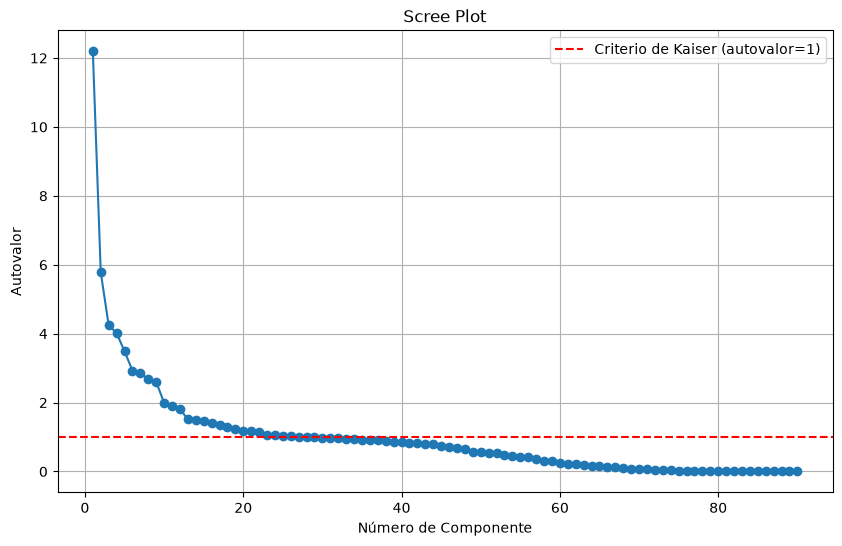

In [14]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(autovalores)+1), autovalores, marker='o')
plt.axhline(y=1, color='r', linestyle='--', label='Criterio de Kaiser (autovalor=1)')
plt.xlabel('Número de Componente')
plt.ylabel('Autovalor')
plt.title('Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

# Interpretación: Selección del número de componentes

Los tres criterios evaluados muestran resultados distintos: el scree plot sugiere un 
codo marcado entre los componentes 5 y 7, el criterio de Kaiser retiene 29 componentes, 
y la varianza acumulada al 70% y 80% sugiere 26 y 35 componentes respectivamente. 

Esta discrepancia es esperable dado que el scree plot prioriza la parsimonia visual, 
mientras que Kaiser tiende a sobreestimar el número de factores cuando el número de 
variables originales es elevado (p=90). Dado que el objetivo del análisis incluye tanto 
la interpretación de factores latentes de riesgo financiero como la posterior 
construcción de un modelo discriminante (LDA), se prioriza retener suficiente 
información explicativa sobre la parsimonia extrema del scree plot.

Se decide retener 26 componentes principales, que corresponden al criterio de varianza 
acumulada ≥70% y son consistentes con el criterio de Kaiser, logrando un balance entre 
reducción de dimensionalidad e información retenida.

# Matriz de cargas (loadings)

In [15]:
# Elegí el número final de componentes (ej. 26)
n_componentes_final = 26

pca_final = PCA(n_components=n_componentes_final)
scores = pca_final.fit_transform(X_scaled)

# Matriz de cargas (loadings) = autovectores × sqrt(autovalores)
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
loadings_df = pd.DataFrame(
    loadings[:, :3],
    index=X_pca.columns,
    columns=['PC1', 'PC2', 'PC3']
)

# Top 10 variables con mayor carga absoluta en cada componente
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n--- Top variables en {pc} ---")
    print(loadings_df[pc].abs().sort_values(ascending=False).head(10))


--- Top variables en PC1 ---
Persistent EPS in the Last Four Seasons                    0.871350
ROA(A) before interest and % after tax                     0.866046
ROA(C) before interest and depreciation before interest    0.863528
ROA(B) before interest and depreciation after tax          0.856500
Net profit before tax/Paid-in capital                      0.852968
Per Share Net profit before tax (Yuan ¥)                   0.848345
Net Income to Total Assets                                 0.828706
Operating Profit Per Share (Yuan ¥)                        0.797113
Operating profit/Paid-in capital                           0.794499
Net Value Per Share (A)                                    0.720797
Name: PC1, dtype: float64

--- Top variables en PC2 ---
Liability to Equity                            0.850910
Current Liabilities/Equity                     0.836894
Borrowing dependency                           0.788359
Inventory and accounts receivable/Net value    0.667657
Equity to 

# Interpretación de la matriz de cargas (loadings)

El análisis de las cargas en las tres primeras componentes principales revela una 
estructura financiera coherente:

- **PC1 (Rentabilidad):** dominada por indicadores de retorno sobre activos y capital 
  (ROA(A), ROA(B), ROA(C), EPS persistente, utilidad sobre capital pagado). Representa 
  la capacidad de la empresa de generar ganancias.

- **PC2 (Apalancamiento/Solvencia):** dominada por Liability to Equity, Current 
  Liabilities/Equity y Borrowing dependency. Representa el nivel de endeudamiento 
  relativo al patrimonio de la empresa.

- **PC3 (Márgenes Operativos/Liquidez de Fondos):** combina Cash flow rate, Operating 
  Gross Margin y Operating Funds to Liability. Representa la eficiencia operativa y 
  la capacidad de los fondos generados para cubrir obligaciones.

Se observa cierto solapamiento de variables entre PC2 y PC3 (p. ej. "Net Income to 
Stockholder's Equity" y "Borrowing dependency"), lo cual es esperable dada la alta 
interrelación conceptual entre los ratios financieros de solvencia y rentabilidad 
sobre patrimonio.

# Biplot / proyección PC1 vs PC2

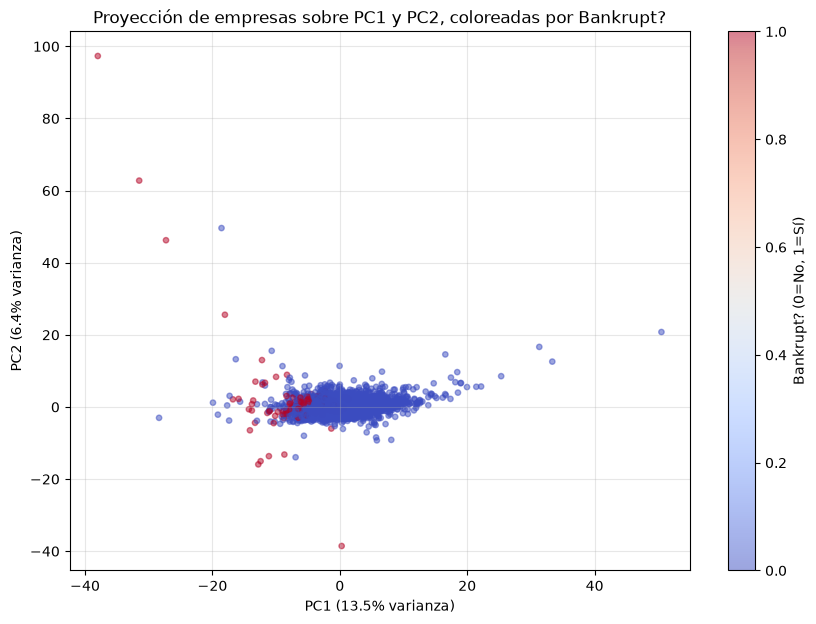

In [16]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    scores[:, 0], scores[:, 1],
    c=y, cmap='coolwarm', alpha=0.5, s=15
)
plt.xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)')
plt.title('Proyección de empresas sobre PC1 y PC2, coloreadas por Bankrupt?')
plt.colorbar(scatter, label='Bankrupt? (0=No, 1=Sí)')
plt.grid(True, alpha=0.3)
plt.show()

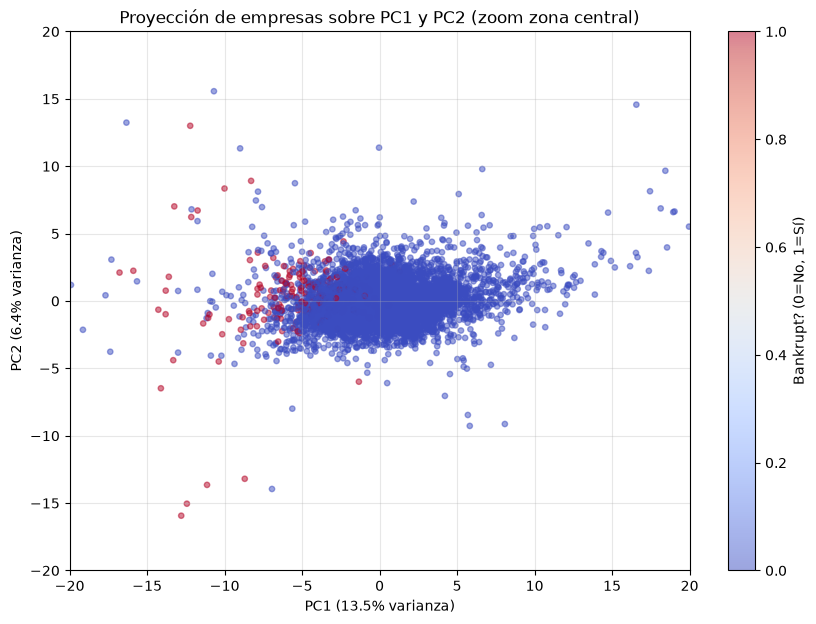

In [17]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    scores[:, 0], scores[:, 1],
    c=y, cmap='coolwarm', alpha=0.5, s=15
)
plt.xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)')
plt.title('Proyección de empresas sobre PC1 y PC2 (zoom zona central)')
plt.colorbar(scatter, label='Bankrupt? (0=No, 1=Sí)')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.grid(True, alpha=0.3)
plt.show()

# Interpretación: Biplot PC1 vs PC2

La proyección de las empresas sobre las dos primeras componentes principales no 
muestra una separación clara entre empresas en quiebra (Bankrupt?=1) y empresas 
solventes (Bankrupt?=0); ambos grupos se superponen en la misma región central del 
plano. Esto se explica por dos factores: (1) el fuerte desbalance de clases del 
dataset, donde las empresas en quiebra representan una proporción muy pequeña del 
total, y (2) la baja varianza acumulada explicada por estas dos componentes (13.5% 
y 6.4%, ~20% en conjunto), lo que indica que la información discriminante entre 
clases —de existir— se distribuye a lo largo de un mayor número de componentes y no 
es capturable en una proyección bidimensional.

Este resultado es relevante de cara al Análisis Discriminante Lineal (punto 1.3): 
anticipa que la separación lineal entre clases usando pocas dimensiones será 
limitada, y que el desbalance de clases deberá tratarse explícitamente (por ejemplo, 
evaluando métricas robustas al desbalance como F1-score o AUC-ROC en lugar de solo 
accuracy).

# Análisis Factorial (AF)

In [18]:
from factor_analyzer import FactorAnalyzer

# Usamos el mismo número de factores decidido en PCA (26) como punto de partida,
# aunque en AF es común iterar y quedarse con un número menor si mejora la interpretabilidad
n_factores = 26

fa = FactorAnalyzer(n_factors=n_factores, method='ml', rotation='promax')
fa.fit(X_scaled)

d:\Github\Especialidad\Business_Analytics\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Github\Especialidad\Business_Analytics\.venv\Lib\site-packages\factor_analyzer\factor_analyzer.py:574: UserWarning: Failed to converge: ABNORMAL: 
  warnings.warn(f"Failed to converge: {res.message}")


,n_factors,26
,rotation,'promax'
,method,'ml'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [19]:
fa = FactorAnalyzer(n_factors=n_factores, method='principal', rotation='promax')
fa.fit(X_scaled)

d:\Github\Especialidad\Business_Analytics\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,26
,rotation,'promax'
,method,'principal'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [20]:
comunalidades = fa.get_communalities()
com_df = pd.Series(comunalidades, index=X_pca.columns).sort_values()

print("Variables con menor comunalidad (candidatas a remover):")
print(com_df.head(15))

print("\nResumen de comunalidades:")
print(com_df.describe())

Variables con menor comunalidad (candidatas a remover):
Long-term Liability to Current Assets                 0.117602
No-credit Interval                                    0.177939
Total Asset Growth Rate                               0.266402
Tax rate (A)                                          0.273747
Total Asset Return Growth Rate Ratio                  0.277748
Quick Assets/Current Liability                        0.290541
Operating Expense Rate                                0.291914
Interest-bearing debt interest rate                   0.306966
Cash Turnover Rate                                    0.324561
Degree of Financial Leverage (DFL)                    0.328682
Interest Coverage Ratio (Interest expense to EBIT)    0.348055
Total assets to GNP price                             0.350503
Operating profit per person                           0.353005
Research and development expense rate                 0.396258
Allocation rate per person                            0.421596

In [21]:
varianza_fa = fa.get_factor_variance()
# Devuelve: (SS Loadings, Proportion Var, Cumulative Var)

var_df = pd.DataFrame(
    varianza_fa,
    index=['SS Loadings', 'Varianza Proporcional', 'Varianza Acumulada'],
    columns=[f'Factor{i+1}' for i in range(n_factores)]
).T

print(var_df.head(10))

          SS Loadings  Varianza Proporcional  Varianza Acumulada
Factor1      7.161864               0.079576            0.079576
Factor2      5.402493               0.060028            0.139604
Factor3      3.814336               0.042382            0.181985
Factor4      4.016721               0.044630            0.226616
Factor5      3.315802               0.036842            0.263458
Factor6      3.120262               0.034670            0.298128
Factor7      2.821160               0.031346            0.329474
Factor8      2.834897               0.031499            0.360973
Factor9      3.683515               0.040928            0.401901
Factor10     3.995597               0.044396            0.446296


In [22]:
loadings_fa = pd.DataFrame(
    fa.loadings_,
    index=X_pca.columns,
    columns=[f'Factor{i+1}' for i in range(n_factores)]
)

# Ver las variables con mayor carga en los primeros 5 factores (los más interpretables)
for factor in [f'Factor{i+1}' for i in range(5)]:
    print(f"\n--- Top variables en {factor} ---")
    print(loadings_fa[factor].abs().sort_values(ascending=False).head(8))


--- Top variables en Factor1 ---
Net Value Per Share (B)                     0.927178
Net Value Per Share (A)                     0.926444
Net Value Per Share (C)                     0.926299
Persistent EPS in the Last Four Seasons     0.898143
Per Share Net profit before tax (Yuan ¥)    0.888871
Net profit before tax/Paid-in capital       0.877499
Operating Profit Per Share (Yuan ¥)         0.849120
Operating profit/Paid-in capital            0.846719
Name: Factor1, dtype: float64

--- Top variables en Factor2 ---
Borrowing dependency                           0.970522
Liability to Equity                            0.969031
Current Liabilities/Equity                     0.890064
Equity to Long-term Liability                  0.859615
Net Income to Stockholder's Equity             0.815800
Inventory and accounts receivable/Net value    0.691481
Contingent liabilities/Net worth               0.538075
Working Capital/Equity                         0.517519
Name: Factor2, dtype: float64


# Selección e interpretación del número de factores

Para el AF no se debe asumir automáticamente el mismo número de dimensiones retenido por PCA. Se comparan la varianza acumulada, el criterio de autovalores y la interpretabilidad de las cargas. La rotación Promax es adecuada porque los constructos financieros (solvencia, liquidez, rentabilidad y eficiencia) pueden estar correlacionados. El método `principal` se utiliza como extracción exploratoria; como análisis de sensibilidad puede repetirse con `method='ml'` si se considera razonable el supuesto de normalidad multivariada.

Se inspeccionan las comunalidades para detectar indicadores con poca varianza común. Una comunalidad inferior a 0.30 se considera una señal para revisar o eliminar la variable, pero la decisión final también debe considerar su significado financiero y no únicamente un umbral mecánico.

In [23]:
# Diagnóstico adicional del AF y comparación PCA vs. AF
n_factores_sugeridos = int(np.argmax(var_df['Varianza Acumulada'].to_numpy() >= 0.70) + 1)
print(f"Factores para alcanzar 70% de varianza común: {n_factores_sugeridos}")
print(f"Factores ajustados inicialmente: {n_factores}")

print("\nCandidatas por comunalidad < 0.30:")
print(com_df[com_df < 0.30])

comparacion = pd.DataFrame({
    'Metodo': ['PCA', 'AF'],
    'Dimensiones retenidas': [n_componentes_final, n_factores],
    'Varianza acumulada reportada': [
        pca_final.explained_variance_ratio_.sum(),
        var_df['Varianza Acumulada'].iloc[-1]
    ],
    'Objetivo': [
        'Maximizar varianza total; componentes ortogonales',
        'Explicar varianza comun; factores latentes rotados'
    ],
    'Interpretacion': [
        'Combinaciones matematicas de los ratios',
        'Constructos subyacentes potencialmente correlacionados'
    ]
})
comparacion

Factores para alcanzar 70% de varianza común: 23
Factores ajustados inicialmente: 26

Candidatas por comunalidad < 0.30:
Long-term Liability to Current Assets    0.117602
No-credit Interval                       0.177939
Total Asset Growth Rate                  0.266402
Tax rate (A)                             0.273747
Total Asset Return Growth Rate Ratio     0.277748
Quick Assets/Current Liability           0.290541
Operating Expense Rate                   0.291914
dtype: float64


,Metodo,Dimensiones retenidas,Varianza acumulada reportada,Objetivo,Interpretacion
0,PCA,26,0.709566,Maximizar varianza total; componentes ortogonales,Combinaciones matematicas de los ratios
1,AF,26,0.752285,Explicar varianza comun; factores latentes rot...,Constructos subyacentes potencialmente correla...


# Análisis Discriminante Lineal (LDA)

La respuesta es `Bankrupt?` (0 = no quiebra, 1 = quiebra). Se utiliza una partición estratificada 80/20. El escalado, el PCA y el ajuste del LDA se realizan dentro del conjunto de entrenamiento; así, el conjunto de prueba permanece completamente separado.

In [24]:
from scipy.stats import normaltest, skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    confusion_matrix, classification_report, recall_score, f1_score,
    roc_auc_score, roc_curve, accuracy_score
)
import pingouin as pg

print("Distribución de clases:")
print(y.value_counts().rename({0: 'No quiebra', 1: 'Quiebra'}))
print((y.value_counts(normalize=True) * 100).round(2).rename({0: 'No quiebra', 1: 'Quiebra'}))

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, stratify=y, random_state=42
)

scaler_lda = StandardScaler()
X_train_scaled = scaler_lda.fit_transform(X_train)
X_test_scaled = scaler_lda.transform(X_test)

# Normalidad: en 90 dimensiones se reporta un diagnóstico operativo por grupo.
normalidad = []
for clase in sorted(y_train.unique()):
    datos_clase = X_train_scaled[y_train.to_numpy() == clase]
    pruebas = [normaltest(datos_clase[:, j]).pvalue for j in range(datos_clase.shape[1])]
    normalidad.append({
        'Clase': clase,
        'Variables que no rechazan normalidad (p>0.05)': int(np.sum(np.array(pruebas) > 0.05)),
        'Mediana |asimetría|': float(np.median(np.abs(skew(datos_clase, axis=0, nan_policy='omit')))),
        'Mediana |curtosis|': float(np.median(np.abs(kurtosis(datos_clase, axis=0, nan_policy='omit'))))
    })
print("\nDiagnóstico univariado resumido de normalidad:")
print(pd.DataFrame(normalidad))

# M de Box: evalúa igualdad de matrices de covarianzas entre las clases.
box_m = pg.box_m(
    data=pd.DataFrame(X_train_scaled, columns=X_pca.columns).assign(grupo=y_train.to_numpy()),
    dvs=list(X_pca.columns),
    group='grupo'
)
print("\nPrueba M de Box:")
print(box_m)

# PCA ajustado únicamente con el entrenamiento.
pca_lda = PCA(n_components=n_componentes_final)
X_train_pca = pca_lda.fit_transform(X_train_scaled)
X_test_pca = pca_lda.transform(X_test_scaled)

print(f"\nVarianza retenida por los scores PCA para LDA: {pca_lda.explained_variance_ratio_.sum():.3f}")

Distribución de clases:
Bankrupt?
No quiebra    6599
Quiebra        220
Name: count, dtype: int64
Bankrupt?
No quiebra    96.77
Quiebra        3.23
Name: proportion, dtype: float64

Diagnóstico univariado resumido de normalidad:
   Clase  Variables que no rechazan normalidad (p>0.05)  Mediana |asimetría|  \
0      0                                              0            12.571244   
1      1                                              1             4.147820   

   Mediana |curtosis|  
0          396.857302  
1           30.945603  


d:\Github\Especialidad\Business_Analytics\.venv\Lib\site-packages\pingouin\multivariate.py:372: RuntimeWarning: invalid value encountered in power
  M = ((np.linalg.det(covs) / S_det) ** (v / 2)).prod()



Prueba M de Box:
     Chi2      df  pval  equal_cov
box   NaN  4095.0   NaN      False

Varianza retenida por los scores PCA para LDA: 0.742


In [25]:
# Ajuste y evaluación de LDA con variables originales y con scores PCA
lda_original = LinearDiscriminantAnalysis(solver='svd')
lda_pca = LinearDiscriminantAnalysis(solver='svd')
lda_original.fit(X_train_scaled, y_train)
lda_pca.fit(X_train_pca, y_train)

resultados_lda = []
curvas_roc = {}

for nombre, modelo, X_eval in [
    ('LDA - 90 variables', lda_original, X_test_scaled),
    (f'LDA - {n_componentes_final} scores PCA', lda_pca, X_test_pca)
]:
    predicciones = modelo.predict(X_eval)
    probabilidades = modelo.predict_proba(X_eval)[:, 1]
    matriz = confusion_matrix(y_test, predicciones)
    tn, fp, fn, tp = matriz.ravel()
    resultados_lda.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, predicciones),
        'Sensibilidad (Recall)': recall_score(y_test, predicciones, zero_division=0),
        'Especificidad': tn / (tn + fp),
        'F1': f1_score(y_test, predicciones, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, probabilidades),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })
    curvas_roc[nombre] = roc_curve(y_test, probabilidades)
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, predicciones, target_names=['No quiebra', 'Quiebra'], zero_division=0))
    print("Matriz de confusión:\n", matriz)

resultados_lda_df = pd.DataFrame(resultados_lda).set_index('Modelo')
print("\nComparación de desempeño:")
display(resultados_lda_df.round(4))

# Coeficientes estandarizados y correlaciones estructurales del LDA original.
coeficientes = pd.Series(lda_original.coef_[0], index=X_pca.columns)
score_entrenamiento = lda_original.decision_function(X_train_scaled)
correlaciones_estructurales = pd.Series(
    [np.corrcoef(X_train_scaled[:, j], score_entrenamiento)[0, 1]
     for j in range(X_train_scaled.shape[1])],
    index=X_pca.columns
)
interpretacion_lda = pd.DataFrame({
    'Coeficiente estandarizado': coeficientes,
    'Correlacion estructural': correlaciones_estructurales
})
print("\nVariables con mayor contribución absoluta al LDA:")
display(interpretacion_lda.reindex(
    interpretacion_lda['Coeficiente estandarizado'].abs().sort_values(ascending=False).index
).head(15).round(4))


--- LDA - 90 variables ---
              precision    recall  f1-score   support

  No quiebra       0.98      0.98      0.98      1320
     Quiebra       0.36      0.34      0.35        44

    accuracy                           0.96      1364
   macro avg       0.67      0.66      0.66      1364
weighted avg       0.96      0.96      0.96      1364

Matriz de confusión:
 [[1293   27]
 [  29   15]]

--- LDA - 26 scores PCA ---
              precision    recall  f1-score   support

  No quiebra       0.97      0.99      0.98      1320
     Quiebra       0.32      0.20      0.25        44

    accuracy                           0.96      1364
   macro avg       0.65      0.60      0.61      1364
weighted avg       0.95      0.96      0.96      1364

Matriz de confusión:
 [[1301   19]
 [  35    9]]

Comparación de desempeño:


,Accuracy,Sensibilidad (Recall),Especificidad,F1,AUC-ROC,TN,FP,FN,TP
Modelo,,,,,,,,,
LDA - 90 variables,0.9589,0.3409,0.9795,0.3488,0.9199,1293,27,29,15
LDA - 26 scores PCA,0.9604,0.2045,0.9856,0.2500,0.8654,1301,19,35,9



Variables con mayor contribución absoluta al LDA:


,Coeficiente estandarizado,Correlacion estructural
Net Value Per Share (C),19.2118,-0.3729
Net Value Per Share (A),-15.2951,-0.3750
Pre-tax net Interest Rate,11.1125,-0.0202
Operating Profit Rate,8.2111,-0.0003
Liability to Equity,7.6618,0.3863
Current Liabilities/Equity,-7.5398,0.3742
After-tax net Interest Rate,-7.4709,-0.0209
Continuous interest rate (after tax),-5.6568,-0.0203
Net Income to Total Assets,-5.0306,-0.6860
Working capitcal Turnover Rate,4.4415,-0.0091


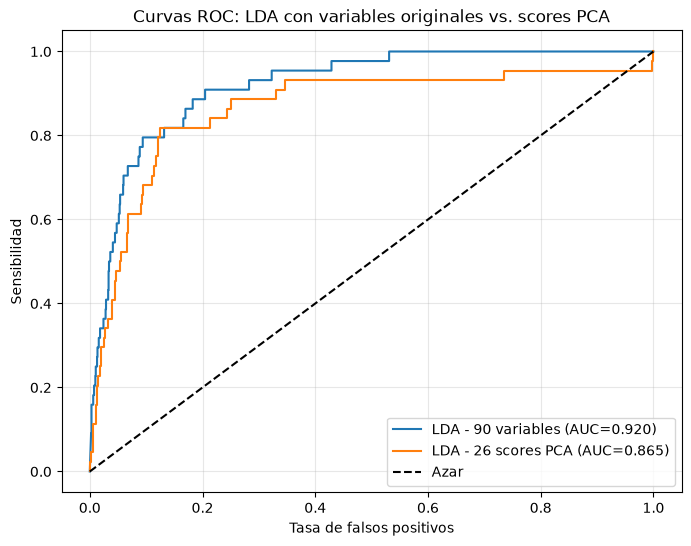

In [26]:
plt.figure(figsize=(8, 6))
for nombre, (false_positive_rate, true_positive_rate, _) in curvas_roc.items():
    auc = resultados_lda_df.loc[nombre, 'AUC-ROC']
    plt.plot(false_positive_rate, true_positive_rate, label=f'{nombre} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Sensibilidad')
plt.title('Curvas ROC: LDA con variables originales vs. scores PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Conclusiones del Punto 1

- **PCA:** Bartlett significativo y KMO global de 0.761 justifican trabajar con la matriz de correlación. Se retuvieron 26 componentes para superar 70% de varianza total (70.96%). El criterio de Kaiser retiene 29 componentes, mientras que el umbral de 80% requiere 35; el scree plot sugiere una solución más parsimoniosa. La elección de 26 es un compromiso entre información y reducción.
- **AF:** con rotación Promax se retienen inicialmente 26 factores, aunque 23 alcanzan 70% de varianza común. Las variables con comunalidad menor a 0.30 son candidatas para revisión. Las cargas deben interpretarse por grupos de variables con el mismo signo y significado financiero, evitando asignar un constructo solo por una carga aislada.
- **LDA:** la normalidad multivariada no resulta plausible y M de Box no puede estimarse de forma estable (`NaN`), por lo que los supuestos clásicos se incumplen. El desbalance 96.77%/3.23% hace que la accuracy sea insuficiente; deben priorizarse recall, F1, especificidad y AUC-ROC.
- **Comparación:** el LDA con variables originales supera al LDA basado en los 26 scores PCA en AUC, recall y F1. La reducción es útil para representar y visualizar, pero en este caso no conserva toda la información necesaria para clasificar quiebras. Los coeficientes del LDA deben interpretarse con cautela por la colinealidad entre ratios.

Para una versión más orientada a decisión de riesgo, conviene añadir como análisis de sensibilidad un umbral de clasificación inferior a 0.5 o ponderación de clases, reportando cómo cambia el recall de empresas quebradas y la tasa de falsos positivos.

## Nota metodologica de las correcciones

- **PCA:** se retienen 26 componentes como una decisión exploratoria basada en alcanzar al menos 70% de varianza acumulada; no se afirma que los criterios de Kaiser, varianza acumulada y scree plot produzcan la misma cantidad.
- **AF:** los 26 factores son una solución inicial exploratoria. El modelo final utiliza extracción por componentes principales y rotación Promax; por tanto, la interpretación se basa en comunalidades y cargas, no en asumir automáticamente que PCA y AF deben conservar el mismo número de dimensiones.
- **LDA:** el diagnóstico de normalidad corresponde a pruebas univariadas por variable, no a una validación formal de normalidad multivariada. La prueba M de Box no fue estable en la dimensión original, por lo que los supuestos clásicos de LDA no se consideran plenamente confirmados.
- **CA/MCA:** la CA de la tabla `2 x 3` tiene una sola dimensión no nula. El mapa bidimensional interpretable se obtiene con el MCA. En el MCA se distinguen las categorías `No aplica`, `Bajo_medio` y `Alto`, y se reporta la corrección de inercia de Benzécri.

# Punto 2: ANÁLISIS DE CORRESPONDENCIAS EN LA EXPERIENCIA DEL CLIENTE (CA / MCA)

Se puede encontrar el dataset en kaggle
- https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

In [50]:
# EDA basico del dataset del punto 2
import pandas as pd

ruta_pasajeros = "Airpassengers/train.csv"
pasajeros = pd.read_csv(ruta_pasajeros)

print(f"Longitud del dataset: {len(pasajeros):,} filas")
print(f"Numero de columnas: {pasajeros.shape[1]}")
print(f"Dimensiones: {pasajeros.shape[0]:,} filas x {pasajeros.shape[1]} columnas")

print("\nColumnas y tipos de datos:")
display(pd.DataFrame({
    "columna": pasajeros.columns,
    "tipo_dato": pasajeros.dtypes.astype(str).values,
}))

nulos = pasajeros.isna().sum()
print(f"\nValores nulos totales: {nulos.sum():,}")
print("Nulos por columna:")
display(nulos[nulos > 0].to_frame("cantidad_nulos"))

print(f"\nFilas duplicadas: {pasajeros.duplicated().sum():,}")
print(f"IDs duplicados: {pasajeros['id'].duplicated().sum():,}")

Longitud del dataset: 103,904 filas
Numero de columnas: 25
Dimensiones: 103,904 filas x 25 columnas

Columnas y tipos de datos:


,columna,tipo_dato
0,Unnamed: 0,int64
1,id,int64
2,Gender,str
3,Customer Type,str
4,Age,int64
5,Type of Travel,str
6,Class,str
7,Flight Distance,int64
8,Inflight wifi service,int64
9,Departure/Arrival time convenient,int64



Valores nulos totales: 310
Nulos por columna:


,cantidad_nulos
Arrival Delay in Minutes,310



Filas duplicadas: 0
IDs duplicados: 0


## 2.1.1. Tabla de contingencia y prueba de independencia

Se cruza la satisfacción global con la clase de vuelo. La prueba $\chi^2$ de Pearson determina si ambas variables son independientes. Los residuos ajustados permiten localizar las celdas con asociaciones significativas: valores mayores que 1.96 indican atracción y menores que -1.96 indican repulsión, aproximadamente con $\alpha=0.05$.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Datos del caso de negocio
pasajeros = pd.read_csv("Airpassengers/train.csv")
pasajeros["satisfecho"] = pasajeros["satisfaction"].eq("satisfied")

# Tabla de contingencia: satisfaction x Class
tabla_ca = pd.crosstab(pasajeros["satisfaction"], pasajeros["Class"])
print("Tabla de contingencia")
display(tabla_ca)

chi2_ca, p_ca, gl_ca, esperados_ca = chi2_contingency(tabla_ca, correction=False)
residuos_estandarizados = (tabla_ca - esperados_ca) / np.sqrt(esperados_ca)

# Residuo ajustado: estandariza tambien por los margenes fila y columna
n_ca = tabla_ca.to_numpy().sum()
proporcion_filas = tabla_ca.sum(axis=1).to_numpy() / n_ca
proporcion_columnas = tabla_ca.sum(axis=0).to_numpy() / n_ca
residuos_ajustados = residuos_estandarizados.to_numpy() / np.sqrt(
    (1 - proporcion_filas)[:, None] * (1 - proporcion_columnas)[None, :]
)
residuos_ajustados = pd.DataFrame(
    residuos_ajustados, index=tabla_ca.index, columns=tabla_ca.columns
)

print(f"Chi-cuadrado = {chi2_ca:.2f}; gl = {gl_ca}; p-valor = {p_ca:.4e}")
print("Residuos estandarizados")
display(residuos_estandarizados.round(2))
print("Residuos ajustados (|residuo| >= 1.96: asociacion significativa)")
display(residuos_ajustados.round(2))

Tabla de contingencia


Class,Business,Eco,Eco Plus
satisfaction,,,
neutral or dissatisfied,15185,38044,5650
satisfied,34480,8701,1844


Chi-cuadrado = 26471.86; gl = 2; p-valor = 0.0000e+00
Residuos estandarizados


Class,Business,Eco,Eco Plus
satisfaction,,,
neutral or dissatisfied,-77.24,71.00,21.54
satisfied,88.33,-81.19,-24.63


Residuos ajustados (|residuo| >= 1.96: asociacion significativa)


Class,Business,Eco,Eco Plus
satisfaction,,,
neutral or dissatisfied,-162.41,145.41,33.96
satisfied,162.41,-145.41,-33.96


## 2.1.2. Inercia y descomposicion de la tabla CA

La inercia total mide la asociacion global entre filas y columnas. Se descompone mediante la SVD de la matriz de residuos estandarizados. Como esta tabla tiene 2 filas y 3 columnas, el rango maximo es $\min(2-1, 3-1)=1$; por tanto, la CA simple solo tiene una dimension no nula. Esta limitacion se documenta antes de usar el MCA para obtener un mapa genuinamente bidimensional.

In [30]:
# Descomposicion SVD de la tabla de correspondencias
frecuencia_total = tabla_ca.to_numpy().sum()
P_ca = tabla_ca / frecuencia_total
masas_fila = P_ca.sum(axis=1).to_numpy()
masas_columna = P_ca.sum(axis=0).to_numpy()
E_ca = np.outer(masas_fila, masas_columna)
S_ca = (P_ca.to_numpy() - E_ca) / np.sqrt(
    masas_fila[:, None] * masas_columna[None, :]
)

U_ca, valores_singulares_ca, Vt_ca = np.linalg.svd(S_ca, full_matrices=False)
autovalores_ca = valores_singulares_ca ** 2
inercia_total_ca = autovalores_ca.sum()
porcentaje_inercia_ca = 100 * autovalores_ca / inercia_total_ca

inercia_ca = pd.DataFrame({
    "dimension": np.arange(1, len(autovalores_ca) + 1),
    "valor_singular": valores_singulares_ca,
    "autovalor_inercia": autovalores_ca,
    "porcentaje_inercia": porcentaje_inercia_ca,
}).round(4)

print(f"Inercia total = {inercia_total_ca:.4f}")
display(inercia_ca)
print("La segunda dimension es nula porque la tabla 2 x 3 solo permite una dimension CA no trivial.")

Inercia total = 0.2548


,dimension,valor_singular,autovalor_inercia,porcentaje_inercia
0,1,0.5047,0.2548,100.0
1,2,0.0000,0.0000,0.0


La segunda dimension es nula porque la tabla 2 x 3 solo permite una dimension CA no trivial.


## 2.1.3. Mapa simetrico, CTR y cos2 de la CA

Se proyectan simultaneamente los perfiles fila y columna. La primera dimension contiene toda la inercia; la segunda se muestra para evidenciar que es degenerada (coordenadas aproximadamente iguales a cero). CTR indica cuanto contribuye cada punto a una dimension y cos2 indica la calidad de su representacion.

CTR de filas (%)


,Dim 1,Dim 2
satisfaction,,
neutral or dissatisfied,43.33,56.67
satisfied,56.67,43.33


CTR de columnas (%)


,Dim 1,Dim 2
Class,,
Business,52.01,45.87
Eco,43.94,54.13
Eco Plus,4.04,0.00


cos2 de filas


,Dim 1,Dim 2
satisfaction,,
neutral or dissatisfied,1.0,0.0
satisfied,1.0,0.0


cos2 de columnas


,Dim 1,Dim 2
Class,,
Business,1.0,0.0
Eco,1.0,0.0
Eco Plus,1.0,0.0


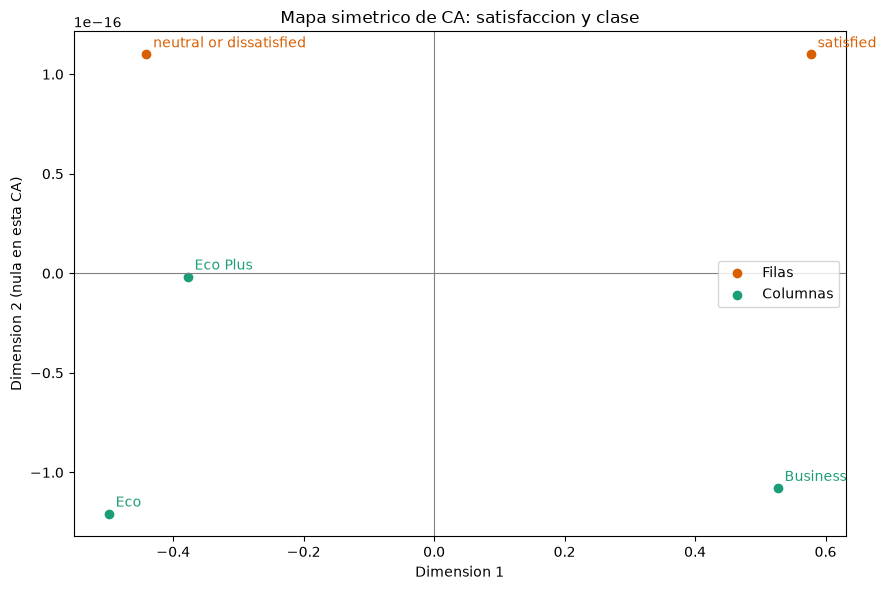

In [31]:
# Coordenadas principales para el mapa simetrico
n_dimensiones = len(valores_singulares_ca)
coordenadas_fila_ca = (
    masas_fila[:, None] ** -0.5
    * U_ca
    * valores_singulares_ca
)
coordenadas_columna_ca = (
    masas_columna[:, None] ** -0.5
    * Vt_ca.T
    * valores_singulares_ca
)

# CTR y cos2, calculados para todas las dimensiones disponibles
ctr_filas_ca = masas_fila[:, None] * coordenadas_fila_ca ** 2
ctr_filas_ca = ctr_filas_ca / np.where(autovalores_ca > 0, autovalores_ca, np.nan)
ctr_columnas_ca = masas_columna[:, None] * coordenadas_columna_ca ** 2
ctr_columnas_ca = ctr_columnas_ca / np.where(autovalores_ca > 0, autovalores_ca, np.nan)

cos2_filas_ca = coordenadas_fila_ca ** 2 / np.where(
    (coordenadas_fila_ca ** 2).sum(axis=1, keepdims=True) > 0,
    (coordenadas_fila_ca ** 2).sum(axis=1, keepdims=True),
    np.nan,
)
cos2_columnas_ca = coordenadas_columna_ca ** 2 / np.where(
    (coordenadas_columna_ca ** 2).sum(axis=1, keepdims=True) > 0,
    (coordenadas_columna_ca ** 2).sum(axis=1, keepdims=True),
    np.nan,
)

nombres_dimensiones = [f"Dim {i + 1}" for i in range(n_dimensiones)]
ctr_filas_df = pd.DataFrame(ctr_filas_ca, index=tabla_ca.index, columns=nombres_dimensiones)
ctr_columnas_df = pd.DataFrame(ctr_columnas_ca, index=tabla_ca.columns, columns=nombres_dimensiones)
cos2_filas_df = pd.DataFrame(cos2_filas_ca, index=tabla_ca.index, columns=nombres_dimensiones)
cos2_columnas_df = pd.DataFrame(cos2_columnas_ca, index=tabla_ca.columns, columns=nombres_dimensiones)

print("CTR de filas (%)")
display((100 * ctr_filas_df).round(2))
print("CTR de columnas (%)")
display((100 * ctr_columnas_df).round(2))
print("cos2 de filas")
display(cos2_filas_df.round(3))
print("cos2 de columnas")
display(cos2_columnas_df.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.scatter(coordenadas_fila_ca[:, 0], coordenadas_fila_ca[:, 1], color="#d95f02", label="Filas")
for etiqueta, (x, y) in zip(tabla_ca.index, coordenadas_fila_ca[:, :2]):
    ax.annotate(etiqueta, (x, y), xytext=(5, 5), textcoords="offset points", color="#d95f02")
ax.scatter(coordenadas_columna_ca[:, 0], coordenadas_columna_ca[:, 1], color="#1b9e77", label="Columnas")
for etiqueta, (x, y) in zip(tabla_ca.columns, coordenadas_columna_ca[:, :2]):
    ax.annotate(etiqueta, (x, y), xytext=(5, 5), textcoords="offset points", color="#1b9e77")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2 (nula en esta CA)")
ax.set_title("Mapa simetrico de CA: satisfaccion y clase")
ax.legend()
plt.tight_layout()
plt.show()

## 2.1.4. MCA para el mapa perceptual bidimensional y los perfiles

Para obtener un plano bidimensional interpretable se utiliza MCA sobre variables categóricas del pasajero y categorías de evaluación de servicios. Las valoraciones se codifican en tres niveles: `0` como `No aplica`, `1-3` como `Bajo_medio` y `4-5` como `Alto`. El MCA se calcula como una CA sobre la matriz disyuntiva completa, conservando la interpretabilidad de cada categoría.

In [48]:
# Construccion del MCA a partir de la matriz disyuntiva completa
mca_base = pasajeros[["satisfaction", "Class", "Type of Travel", "Customer Type"]].copy()
servicios_mca = {
    "Inflight wifi service": "wifi",
    "Online boarding": "boarding",
    "Seat comfort": "seat",
    "Inflight entertainment": "entertainment",
}
for columna, nombre_corto in servicios_mca.items():
    mca_base[nombre_corto] = np.select(
        [
            pasajeros[columna] == 0,
            pasajeros[columna].between(1, 3),
            pasajeros[columna].between(4, 5),
        ],
        ["No aplica", "Bajo_medio", "Alto"],
        default="No informado",
    )

variables_mca = list(mca_base.columns)
indicadores_mca = pd.get_dummies(mca_base.astype(str), prefix_sep="=").astype(float)
n_observaciones, n_categorias_mca = indicadores_mca.shape

# CA de la matriz disyuntiva: cada pasajero tiene la misma masa de fila
Z_mca = indicadores_mca.to_numpy()
P_mca = Z_mca / (n_observaciones * len(variables_mca))
masas_fila_mca = np.full(n_observaciones, 1 / n_observaciones)
masas_columna_mca = Z_mca.sum(axis=0) / (n_observaciones * len(variables_mca))
S_mca = (P_mca - np.outer(masas_fila_mca, masas_columna_mca)) / np.sqrt(
    masas_fila_mca[:, None] * masas_columna_mca[None, :]
)

U_mca, valores_singulares_mca, Vt_mca = np.linalg.svd(S_mca, full_matrices=False)
autovalores_mca = valores_singulares_mca ** 2
inercia_total_mca = autovalores_mca.sum()
porcentaje_inercia_mca = 100 * autovalores_mca / inercia_total_mca

# Correccion de Benzécri para las inercias del MCA
numero_variables_mca = len(variables_mca)
umbral_benzecri = 1 / numero_variables_mca
autovalores_benzecri = np.where(
    autovalores_mca > umbral_benzecri,
    (numero_variables_mca / (numero_variables_mca - 1))
    * (autovalores_mca - umbral_benzecri) ** 2,
    0,
)
porcentaje_benzecri = 100 * autovalores_benzecri / autovalores_benzecri.sum()

inercia_mca = pd.DataFrame({
    "dimension": np.arange(1, len(autovalores_mca) + 1),
    "valor_singular": valores_singulares_mca,
    "autovalor_bruto": autovalores_mca,
    "porcentaje_bruto": porcentaje_inercia_mca,
    "autovalor_benzecri": autovalores_benzecri,
    "porcentaje_benzecri": porcentaje_benzecri,
})

coordenadas_filas_mca = U_mca * valores_singulares_mca * np.sqrt(n_observaciones)
coordenadas_categorias_mca = (
    Vt_mca.T * valores_singulares_mca
    / np.sqrt(masas_columna_mca[:, None])
)

print(f"MCA: {n_observaciones:,} observaciones, {n_categorias_mca} categorias")
print(f"Inercia total MCA bruta = {inercia_total_mca:.4f}")
print(f"Variables activas: {numero_variables_mca}; umbral de Benzécri = {umbral_benzecri:.4f}")
display(inercia_mca.head(8).round(4))

MCA: 103,904 observaciones, 21 categorias
Inercia total MCA bruta = 1.6250
Variables activas: 8; umbral de Benzécri = 0.1250


,dimension,valor_singular,autovalor_bruto,porcentaje_bruto,autovalor_benzecri,porcentaje_benzecri
0,1,0.6241,0.3895,23.9703,0.0800,91.2338
1,2,0.4327,0.1872,11.5206,0.0044,5.0463
2,3,0.4219,0.1780,10.9528,0.0032,3.6603
3,4,0.3628,0.1316,8.1007,0.0001,0.0574
4,5,0.3554,0.1263,7.7724,0.0000,0.0022
5,6,0.3535,0.1250,7.6912,0.0000,0.0000
6,7,0.3527,0.1244,7.6562,0.0000,0.0000
7,8,0.3405,0.1159,7.1346,0.0000,0.0000


## 2.1.5. Mapa MCA, contribuciones (CTR) y calidad (cos2)

Se retienen las dimensiones 1 y 2 porque son las de mayor inercia y juntas explican aproximadamente el 96.28% de la inercia corregida mediante Benzécri. La primera dimensión explica 91.23% y la segunda 5.05%. El mapa se interpreta junto con CTR y cos2; las categorías con baja calidad de representación no deben utilizarse para conclusiones fuertes.

Categorias con mayor CTR en el plano


,CTR acumulada (%)
wifi=No aplica,35.80
boarding=No aplica,30.57
satisfaction=satisfied,14.08
Type of Travel=Personal Travel,11.58
satisfaction=neutral or dissatisfied,10.77
seat=Bajo_medio,10.37
boarding=Alto,10.22
Customer Type=disloyal Customer,9.67
boarding=Bajo_medio,9.31
entertainment=Bajo_medio,9.10


Categorias mejor representadas en el plano (cos2 acumulado)


,cos2 acumulado
satisfaction=satisfied,0.747
satisfaction=neutral or dissatisfied,0.747
boarding=Alto,0.602
wifi=No aplica,0.559
boarding=Bajo_medio,0.557
seat=Bajo_medio,0.501
seat=Alto,0.501
boarding=No aplica,0.470
entertainment=Alto,0.467
entertainment=Bajo_medio,0.466


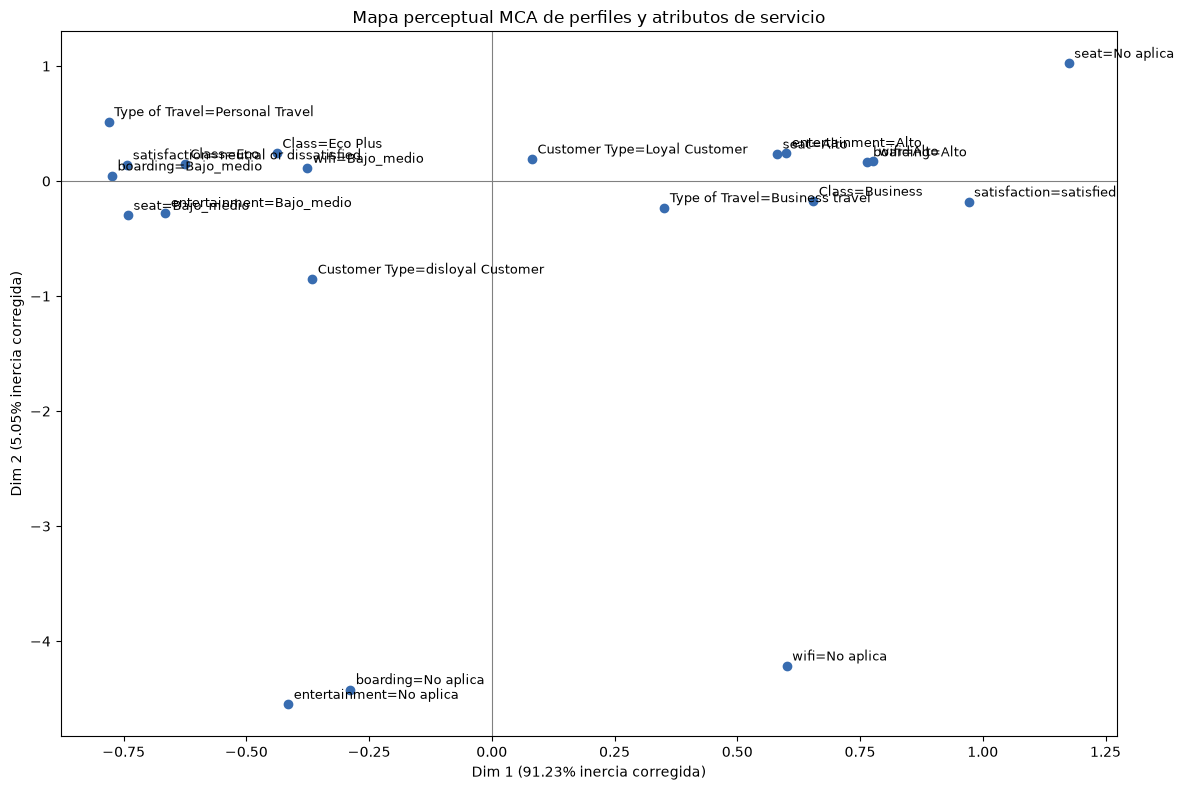

In [49]:
dimensiones_mca = [0, 1]
coord_mca_2d = coordenadas_categorias_mca[:, dimensiones_mca]
ctr_categorias_mca = (
    masas_columna_mca[:, None] * coord_mca_2d ** 2
    / autovalores_mca[dimensiones_mca]
)
cos2_categorias_mca = coord_mca_2d ** 2 / np.maximum(
    (coordenadas_categorias_mca ** 2).sum(axis=1, keepdims=True), 1e-12
)

ctr_mca_df = pd.DataFrame(
    100 * ctr_categorias_mca,
    index=indicadores_mca.columns,
    columns=["Dim 1", "Dim 2"],
)
cos2_mca_df = pd.DataFrame(
    cos2_categorias_mca,
    index=indicadores_mca.columns,
    columns=["Dim 1", "Dim 2"],
)
coordenadas_mca_df = pd.DataFrame(
    coord_mca_2d,
    index=indicadores_mca.columns,
    columns=["Dim 1", "Dim 2"],
)

print("Categorias con mayor CTR en el plano")
display(ctr_mca_df.sum(axis=1).sort_values(ascending=False).head(10).round(2).to_frame("CTR acumulada (%)"))
print("Categorias mejor representadas en el plano (cos2 acumulado)")
display(cos2_mca_df.sum(axis=1).sort_values(ascending=False).head(10).round(3).to_frame("cos2 acumulado"))

fig, ax = plt.subplots(figsize=(12, 8))
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.scatter(coord_mca_2d[:, 0], coord_mca_2d[:, 1], color="#386cb0")
for etiqueta, (x, y) in coordenadas_mca_df.iterrows():
    ax.annotate(etiqueta, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel(f"Dim 1 ({porcentaje_benzecri[0]:.2f}% inercia corregida)")
ax.set_ylabel(f"Dim 2 ({porcentaje_benzecri[1]:.2f}% inercia corregida)")
ax.set_title("Mapa perceptual MCA de perfiles y atributos de servicio")
plt.tight_layout()
plt.show()

## 2.2.1. Diagnostico de perfiles de pasajeros

Los perfiles se interpretan por proximidad cualitativa en el mapa MCA: categorias cercanas tienden a aparecer juntas, mientras que las alejadas del origen y en direcciones opuestas representan asociaciones diferentes. La cercania no sustituye una prueba causal; se contrasta con tasas de satisfaccion y medias de servicio por segmento.

In [47]:
# Contraste cuantitativo de los perfiles sugeridos por el mapa MCA
pasajeros["satisfecho"] = pasajeros["satisfaction"].eq("satisfied")

segmentos_perfiles = (
    pasajeros.groupby(["Type of Travel", "Class", "Customer Type"])
    .agg(
        pasajeros=("satisfecho", "size"),
        satisfaccion_pct=("satisfecho", lambda serie: 100 * serie.mean()),
        online_boarding=("Online boarding", "mean"),
        wifi=("Inflight wifi service", "mean"),
        entretenimiento=("Inflight entertainment", "mean"),
        comodidad_asiento=("Seat comfort", "mean"),
    )
    .reset_index()
)

# Se muestran los segmentos con mayor y menor satisfaccion para apoyar el diagnostico
print("Tres segmentos con mayor satisfaccion")
display(
    segmentos_perfiles.sort_values("satisfaccion_pct", ascending=False)
    .head(3)
    .round(2)
)
print("Tres segmentos con menor satisfaccion")
display(
    segmentos_perfiles.sort_values("satisfaccion_pct")
    .head(3)
    .round(2)
)

# Comparacion de los segmentos de negocio mas relevantes
perfiles_clave = pasajeros.groupby(["Type of Travel", "Class"]).agg(
    pasajeros=("satisfecho", "size"),
    satisfaccion_pct=("satisfecho", lambda serie: 100 * serie.mean()),
    online_boarding=("Online boarding", "mean"),
    wifi=("Inflight wifi service", "mean"),
    entretenimiento=("Inflight entertainment", "mean"),
    comodidad_asiento=("Seat comfort", "mean"),
).reset_index()
print("Perfiles clave para la decision")
display(perfiles_clave.sort_values("satisfaccion_pct", ascending=False).round(2))

Tres segmentos con mayor satisfaccion


,Type of Travel,Class,Customer Type,pasajeros,satisfaccion_pct,online_boarding,wifi,entretenimiento,comodidad_asiento
0,Business travel,Business,Loyal Customer,40163,77.95,3.89,2.76,3.77,3.92
2,Business travel,Eco,Loyal Customer,9496,47.38,3.19,3.21,3.26,3.21
4,Business travel,Eco Plus,Loyal Customer,3179,46.37,3.13,3.14,3.23,3.19


Tres segmentos con menor satisfaccion


,Type of Travel,Class,Customer Type,pasajeros,satisfaccion_pct,online_boarding,wifi,entretenimiento,comodidad_asiento
7,Personal Travel,Business,disloyal Customer,11,0.00,2.36,2.73,2.18,2.00
11,Personal Travel,Eco Plus,disloyal Customer,4,0.00,2.50,2.50,2.50,2.50
5,Business travel,Eco Plus,disloyal Customer,711,7.88,2.47,2.46,3.04,3.02


Perfiles clave para la decision


,Type of Travel,Class,pasajeros,satisfaccion_pct,online_boarding,wifi,entretenimiento,comodidad_asiento
0,Business travel,Business,47508,72.02,3.74,2.79,3.66,3.77
2,Business travel,Eco Plus,3890,39.33,3.01,3.01,3.20,3.16
1,Business travel,Eco,20257,29.62,2.87,2.88,3.14,3.10
3,Personal Travel,Business,2157,12.24,3.24,2.55,3.01,3.46
4,Personal Travel,Eco,26488,10.20,2.77,2.52,3.07,3.17
5,Personal Travel,Eco Plus,3604,8.71,2.76,2.50,3.08,3.21


### Interpretacion de tres patrones de asociacion

1. **Viajero de negocios en Business, cliente leal y satisfecho.** En el MCA se ubican cerca `Business travel`, `Class=Business`, `Customer Type=Loyal Customer` y `satisfaction=satisfied`. El contraste cuantitativo confirma 72.0% de satisfacción en el segmento Business travel–Business; es el perfil de referencia de la experiencia positiva.

2. **Viajero de negocios en clase económica con valor percibido intermedio.** `Business travel` asociado a `Class=Eco/Eco Plus` se separa del polo de alta satisfacción de Business. La satisfacción baja a 29.6% en Eco y 39.3% en Eco Plus, con evaluaciones menores en embarque digital, Wi-Fi y comodidad; representa una oportunidad de recuperar valor sin convertir toda la experiencia a premium.

3. **Viajero personal en clases económicas con insatisfacción general.** En el mapa, `Personal Travel`, `Class=Eco/Eco Plus`, `satisfaction=neutral or dissatisfied` y las categorías `Bajo_medio` de asiento, entretenimiento, embarque y Wi-Fi aparecen próximas. En los segmentos de mayor volumen, la satisfacción es 10.2% en Personal Travel–Eco y 8.7% en Personal Travel–Eco Plus.

Como patrón complementario, `Customer Type=disloyal Customer` se aproxima a categorías de servicio bajo y a la insatisfacción. Las categorías `No aplica` se mantienen separadas de las categorías bajas: no deben interpretarse como una mala evaluación, sino como ausencia o no aplicabilidad de la valoración. Los subsegmentos muy pequeños deben tratarse como señal exploratoria y no como base única para decisiones.

## 2.2.2. Recomendaciones de servicio operativo

Las acciones se priorizan con base en la brecha de evaluacion entre pasajeros satisfechos y pasajeros neutrales/insatisfechos, complementada con los perfiles del MCA.

In [37]:
# Priorizacion cuantitativa de los puntos de contacto
variables_servicio = [
    "Inflight wifi service",
    "Ease of Online booking",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
    "Food and drink",
]
promedios_satisfaccion = pasajeros.groupby("satisfaction")[variables_servicio].mean()
brechas_servicio = (
    promedios_satisfaccion.loc["satisfied"]
    - promedios_satisfaccion.loc["neutral or dissatisfied"]
).sort_values(ascending=False)

prioridades_servicio = pd.DataFrame({
    "media_satisfechos": promedios_satisfaccion.loc["satisfied"],
    "media_neutrales_insatisfechos": promedios_satisfaccion.loc["neutral or dissatisfied"],
    "brecha_prioridad": brechas_servicio,
}).sort_values("brecha_prioridad", ascending=False)

print("Puntos de contacto priorizados por brecha")
display(prioridades_servicio.head(8).round(2))

Puntos de contacto priorizados por brecha


,media_satisfechos,media_neutrales_insatisfechos,brecha_prioridad
Online boarding,4.03,2.66,1.37
Inflight entertainment,3.96,2.89,1.07
Seat comfort,3.97,3.04,0.93
On-board service,3.86,3.02,0.84
Leg room service,3.82,2.99,0.83
Cleanliness,3.74,2.94,0.81
Inflight wifi service,3.16,2.40,0.76
Checkin service,3.65,3.04,0.60


### Estrategia 1. Simplificar y asegurar el embarque digital

`Online boarding` tiene la mayor brecha de evaluacion (1.37 puntos). Se recomienda rediseñar el flujo de reserva y check-in movil, hacer visible la tarjeta de embarque y enviar alertas de puerta y cambios de horario. El foco inicial debe ser Personal Travel y Business travel en Eco/Eco Plus. Los KPI son tasa de check-in digital completado, abandonos del flujo, uso de asistencia en mostrador y satisfaccion posterior al check-in.

### Estrategia 2. Recuperar el valor percibido de la cabina economica

`Inflight entertainment` (1.07), `Seat comfort` (0.93) y `Leg room service` (0.83) muestran brechas altas. Se propone auditar el entretenimiento por aeronave, corregir equipos defectuosos, ampliar contenidos y priorizar mejoras de comodidad en rutas largas. En vuelos donde el espacio no pueda modificarse, deben ofrecerse seleccion de asiento y compensaciones transparentes. Los KPI son disponibilidad del entretenimiento, incidencias por vuelo, evaluacion de comodidad y recompra a 90 dias.

### Estrategia 3. Estabilizar la operacion a bordo y la conectividad

`On-board service` (0.84), `Cleanliness` (0.81) e `Inflight wifi service` (0.76) tambien se asocian con la insatisfaccion. Se recomienda usar una lista de verificacion de limpieza entre vuelos, controlar el cumplimiento del servicio por tramo, elevar la confiabilidad del Wi-Fi y comunicar sus limitaciones antes del embarque. Los KPI son disponibilidad real del Wi-Fi, incidencias de limpieza y servicio por 1,000 pasajeros, quejas y satisfaccion por vuelo.

## Conclusión del Punto 2

La CA confirma una asociación estadísticamente significativa entre satisfacción y clase de vuelo. Como la tabla `2 x 3` solo posee una dimensión no nula, su mapa bidimensional es degenerado. El MCA permite representar conjuntamente los perfiles de pasajeros y los atributos de servicio. Después de distinguir `No aplica`, `Bajo_medio` y `Alto`, las dos primeras dimensiones concentran el 96.28% de la inercia corregida mediante Benzécri. La primera dimensión está influida principalmente por la aplicabilidad de algunos servicios, por lo que las categorías `No aplica` no se interpretan como insatisfacción. Las categorías `Bajo_medio`, junto con Personal Travel en clases económicas, se relacionan con el polo de insatisfacción y respaldan las tres estrategias operativas propuestas.

**Priorizacion ejecutiva:** primero embarque digital por su mayor brecha y facilidad de intervencion; segundo, comodidad y entretenimiento en Personal Travel y clases economicas; tercero, Wi-Fi, limpieza y servicio a bordo con seguimiento por aeronave y ruta. Estas son asociaciones observacionales, por lo que la implementacion debe validarse mediante un piloto por rutas comparables y una medicion posterior contra la linea base.